**EL5206 Laboratorio de Inteligencia Computacional y Robótica**

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import random
import math

In [45]:
# Cargamos los datos del laser
my_array = np.load('gt.npy')
# my_array = np.load('odom.npy')
print(my_array)

[[ 2.39060224  0.84330792]
 [ 2.32827095  0.85196129]
 [ 2.24272597  0.84676674]
 ...
 [ 6.1730913  -5.22984143]
 [ 6.23023698 -5.23765266]
 [ 6.28762084 -5.21214495]]


In [46]:
#Eliminamos los elementos que se van a infinito
new_array = []
for i in range(len(my_array)):

  if my_array[i][0] != np.inf:
    new_array.append(my_array[i])
new_array = np.array(new_array)

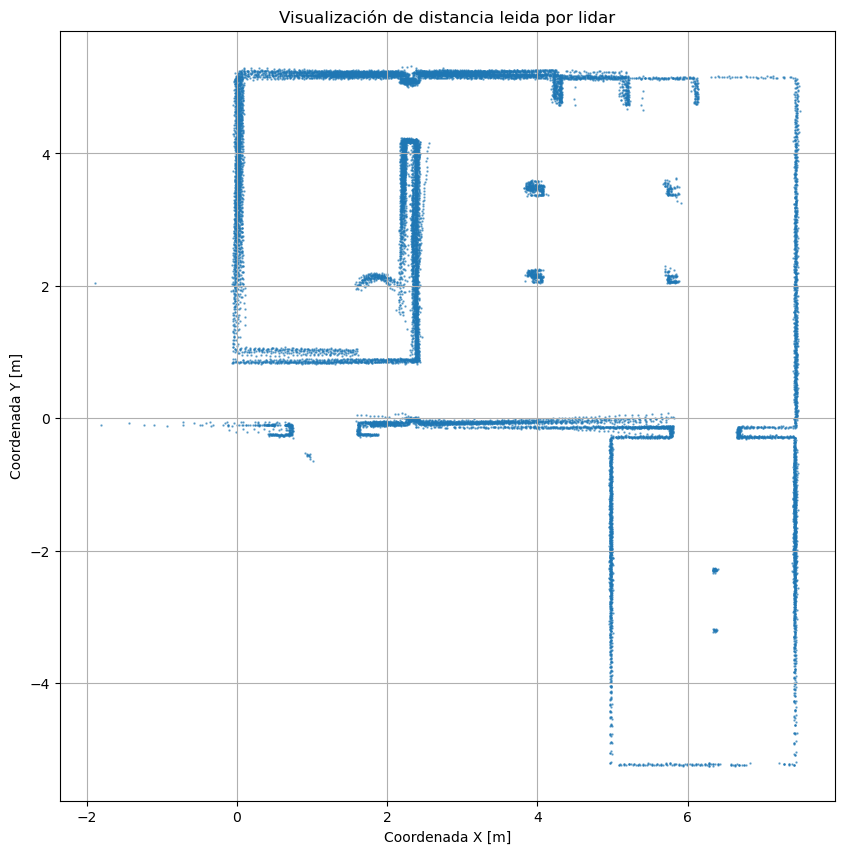

In [47]:
# Mostramos las mediciones en un gráfico
x = []
y = []
for i in range(len(new_array)):
  x.append(new_array[i][0])
  y.append(new_array[i][1])

cartesianas = new_array
plt.figure(figsize=(10,10)) 
plt.scatter(x, y, alpha=0.6, s=0.5)
plt.grid(True)
plt.xlabel('Coordenada X [m]')
plt.ylabel('Coordenada Y [m]')
plt.title('Visualización de distancia leida por lidar')

plt.show()

In [48]:
def distancia_punto_a_recta(punto, m, n):
    # Calcula la distancia entre un punto y una recta
    x, y = punto
    distancia = np.abs(m * x - y + n) / np.sqrt(m**2 + 1)
    return distancia

In [49]:
def line_from_points(p1, p2):
    (x1, y1), (x2, y2) = p1, p2
  # COMPLETAR con la ecuación de la recta de toda la vida
  ## Recta a*x + b*y + c = 0 normalizada (c >= 0) a partir de 2 puntos.

    a = (y1 - y2) / (x2 -x1)
    b = 1
    c = -a*x1-y1
    norm = math.hypot(a, b)
    if norm == 0:
        return None
    a, b, c = a/norm, b/norm, c/norm
    if c < 0:  # consistencia de signos
        a, b, c = -a, -b, -c
    return (a, b, c)

In [50]:
def mn_from_abc(a, b, c):
    if b == 0:
        return float('inf'), float('inf')  # Línea vertical
    m = -a / b
    n = -c / b
    return m, n

In [51]:
def RANSAC(points, dist_thresh, min_inliers, max_iter, max_lines):
    # COMPLETAR
        lines = []
        point_1 = random.choice(points)
        point_2 = random.choice(points)
        line = line_from_points(point_1, point_2)
        for i in range(max_iter):
            inliers = []
            for p in points:
                distance = abs(line[0]*p[0] + line[1]*p[1] + line[2])
                if distance < dist_thresh:
                    inliers.append(p)
            if len(inliers) >= min_inliers:
                lines.append(line)
                if len(lines) >= max_lines:
                    break
                #points = [tuple(p) for p in points]
                points = [p for p in points if p not in inliers]
            point_1 = random.choice(points)
            point_2 = random.choice(points)
            line = line_from_points(point_1, point_2)

            mn = mn_from_abc(line[0], line[1], line[2])
        return mn


In [52]:
def RANSAC(points, dist_thresh, min_inliers, max_iter, max_lines):
    lines = []
    points = np.array(points)  # aseguramos que es array numpy
    for _ in range(max_lines):
        for _ in range(max_iter):
            if len(points) < 2:  # no quedan suficientes puntos
                break

            # Elegimos dos puntos aleatorios
            idx = np.random.choice(len(points), 2, replace=False)
            point_1, point_2 = points[idx]

            # Ecuación de la recta
            line = line_from_points(point_1, point_2)
            if line is None:
                continue

            # Distancia de todos los puntos a la recta
            distances = np.abs(line[0]*points[:,0] + line[1]*points[:,1] + line[2])

            # Inliers y outliers
            inliers_mask = distances < dist_thresh
            inliers = points[inliers_mask]
            points = points[~inliers_mask]  # descartamos los inliers

            # Guardamos línea si tiene suficientes inliers
            if len(inliers) >= min_inliers:
                lines.append(line)
                break
        if len(lines) >= max_lines:
            break
        # return lines
    mn_list = []
    for line in lines:
        mn = mn_from_abc(line[0], line[1], line[2])
        mn_list.append(mn)
    return mn_list


[(np.float64(-132.24286757043203), np.float64(317.9640661096865)), (np.float64(-0.046178425966283326), np.float64(5.305456010697063)), (np.float64(74.47011471375518), np.float64(3.7396821298371665)), (np.float64(781.3944394213634), np.float64(-5802.322111619833)), (np.float64(0.006477293795517098), np.float64(-0.07494596118481521))]


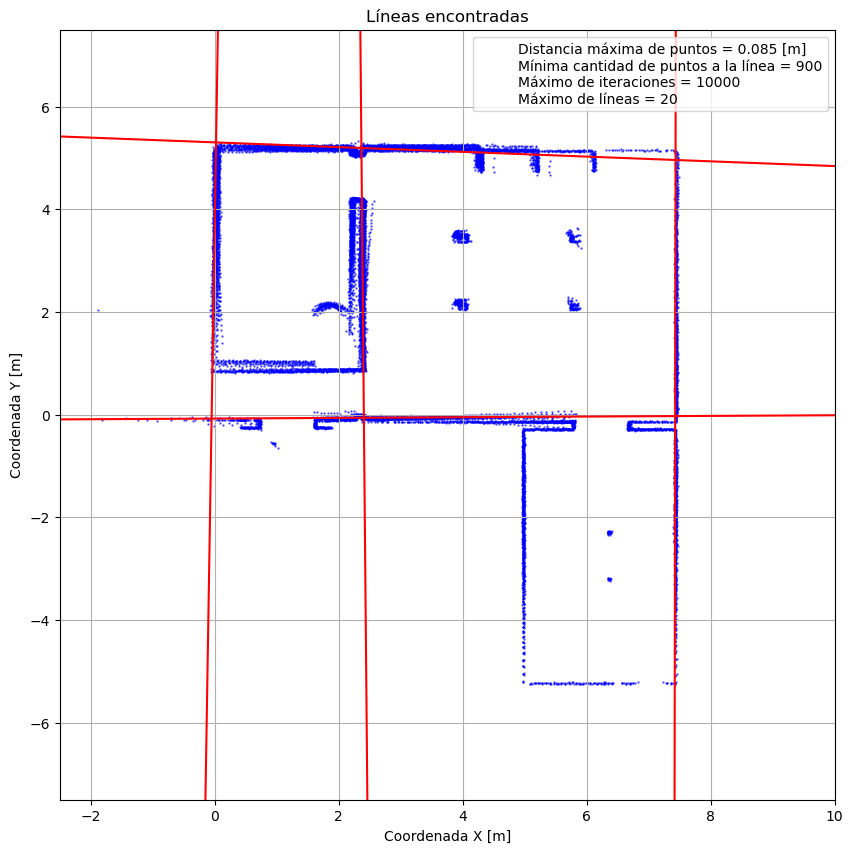

In [ ]:

dist_tresh = 0.09
min_inliers = 900
max_iter = 10000
max_lines = 20
mn = RANSAC(cartesianas, dist_tresh, min_inliers, max_iter, max_lines)
print(mn)

plt.figure(figsize=(10,10))
plt.xlim(-2.5,10)
plt.ylim(-7.5,7.5)

params_text = (
    f"Distancia máxima de puntos = {dist_tresh} [m]\n"
    f"Mínima cantidad de puntos a la línea = {min_inliers}\n"
    f"Máximo de iteraciones = {max_iter}\n"
    f"Máximo de líneas = {max_lines}"
)

for line in mn:
    m, n = line
    x = np.linspace(-10, 10, 100)
    y = m * x + n
    plt.plot(x, y, color='red')

px = [x[0] for x in cartesianas]
py = [x[1] for x in cartesianas]
plt.scatter(px, py, color='blue', alpha=0.6, s=0.5)

custom_legend = [Line2D([0], [0], color='none', label=params_text)]

plt.xlabel('Coordenada X [m]')
plt.ylabel('Coordenada Y [m]')
plt.title('Líneas encontradas')
plt.legend(handles=custom_legend, loc="upper right", frameon=True)
plt.grid(True)
plt.show()


[(np.float64(347.7933348887472), np.float64(-2586.6866787496824)), (np.float64(-0.01593946885323263), np.float64(5.2199696959710655)), (np.float64(-179.7855077690868), np.float64(893.51442018852)), (np.float64(0.003526069478668873), np.float64(5.2142200079777705)), (np.float64(-0.07880672911917602), np.float64(0.28175168005511897)), (np.float64(0.012587159021154488), np.float64(-0.10962586022152082)), (np.float64(55.214339464284784), np.float64(-118.63954380402721)), (np.float64(-25.703412874158957), np.float64(62.24556464011757)), (np.float64(-13.766413621825468), np.float64(34.64979376776181)), (np.float64(-0.05928008781835938), np.float64(5.369620874759796)), (np.float64(-0.03308376758461807), np.float64(5.286927459858407)), (np.float64(-33.18432191057002), np.float64(3.5798782166107466)), (np.float64(-353.93934077253897), np.float64(2623.5409971437693)), (np.float64(0.002458560504158737), np.float64(5.239763070893472)), (np.float64(39.867791137734024), np.float64(3.9466094220433727

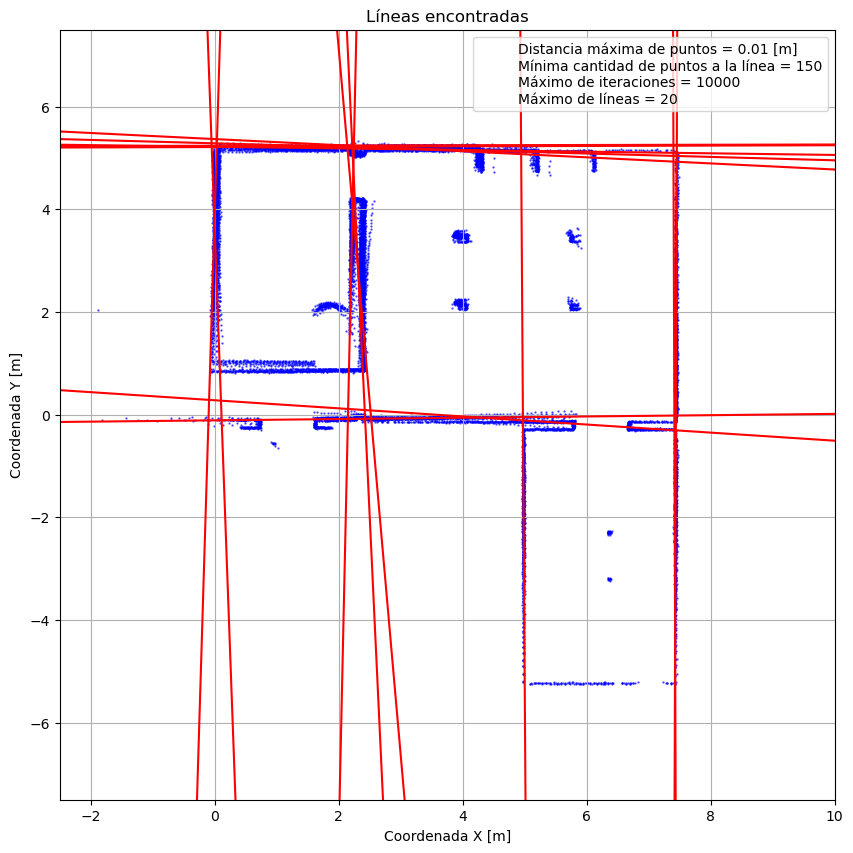

In [134]:
dist_tresh = 0.01
min_inliers = 150
max_iter = 10000
max_lines = 20

mn = RANSAC(cartesianas, dist_tresh, min_inliers, max_iter, max_lines)
print(mn)

plt.figure(figsize=(10,10))
plt.xlim(-2.5,10)
plt.ylim(-7.5,7.5)

params_text = (
    f"Distancia máxima de puntos = {dist_tresh} [m]\n"
    f"Mínima cantidad de puntos a la línea = {min_inliers}\n"
    f"Máximo de iteraciones = {max_iter}\n"
    f"Máximo de líneas = {max_lines}"
)

for line in mn:
    m, n = line
    x = np.linspace(-10, 10, 100)
    y = m * x + n
    plt.plot(x, y, color='red')

px = [x[0] for x in cartesianas]
py = [x[1] for x in cartesianas]
plt.scatter(px, py, color='blue', alpha=0.6, s=0.5)

custom_legend = [Line2D([0], [0], color='none', label=params_text)]

plt.xlabel('Coordenada X [m]')
plt.ylabel('Coordenada Y [m]')
plt.title('Líneas encontradas')
plt.legend(handles=custom_legend, loc="upper right", frameon=True)
plt.grid(True)
plt.show()
